# Exploratory Data Analysis — Deteksi Sarkasme pada Dataset SARC

Notebook ini menganalisis dataset **SARC (Self-Annotated Reddit Corpus) — versi balanced** sebagai dasar tahap preprocessing dan fine-tuning **RoBERTa** dan **DistilBERT** sesuai proposal.

**Tujuan EDA:**
1. Mengaudit kualitas data (noise, duplikat, label bertentangan).
2. Menerapkan dan memeriksa preprocessing sesuai proposal.
3. Memahami distribusi data dan pola leksikal sarkasme.
4. Melihat **pola konteks** antara *comment* dan *parent comment*.
5. Memvalidasi keputusan eksperimen: `max_length = 256` token dan subset ±200.000 pasangan.

**Daftar isi**
0. Setup
1. Load Data
2. Audit Kualitas Data
3. Preprocessing Sesuai Proposal
4. Distribusi Data
5. Analisis Leksikal (WordCloud & N-gram)
6. Analisis Konteks Comment–Parent
7. Kesiapan Data untuk Modeling
8. Kesimpulan EDA

## 0. Setup

In [ ]:
import os
import re, html
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
from scipy.stats import spearmanr, mannwhitneyu
from sklearn.feature_extraction.text import TfidfVectorizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from transformers import AutoTokenizer

SEED = 42
ROOT = Path.cwd().parents[1]
RAW_PATH = ROOT / "data/raw/train-balanced-sarcasm.csv"
FIG_DIR = ROOT / "data/processed/figures/eda"
TAB_DIR = ROOT / "data/processed/tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

LABEL_NAMES = {0: "Non-Sarkas", 1: "Sarkas"}
PALETTE = {"Non-Sarkas": "#3498DB", "Sarkas": "#E74C3C"}
sns.set_theme(style="whitegrid")

def save_fig(name):
    plt.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

print("Working Directory:", os.getcwd())

Working Directory: /Users/hibrizi/Project/TA/experiments/notebooks


## 1. Load Data

In [126]:
df = pd.read_csv(RAW_PATH)

print(df.shape)
df.head()

(1010826, 10)


,label,comment,author,subreddit,score,ups,downs,date,created_utc,parent_comment
0,0,NC and NH.,Trumpbart,politics,2,-1,-1,2016-10,2016-10-16 23:55:23,"Yeah, I get that argument. At this point, I'd ..."
1,0,You do know west teams play against west teams...,Shbshb906,nba,-4,-1,-1,2016-11,2016-11-01 00:24:10,The blazers and Mavericks (The wests 5 and 6 s...
2,0,"They were underdogs earlier today, but since G...",Creepeth,nfl,3,3,0,2016-09,2016-09-22 21:45:37,They're favored to win.
3,0,"This meme isn't funny none of the ""new york ni...",icebrotha,BlackPeopleTwitter,-8,-1,-1,2016-10,2016-10-18 21:03:47,deadass don't kill my buzz
4,0,I could use one of those tools.,cush2push,MaddenUltimateTeam,6,-1,-1,2016-12,2016-12-30 17:00:13,Yep can confirm I saw the tool they use for th...


## 2. Audit Kualitas Data

Pemeriksaan dilakukan pada **data mentah** sebelum preprocessing, untuk mengetahui jenis dan jumlah *noise* yang perlu ditangani.

In [127]:
URL_RE = r"https?://\S+|www\.\S+"
HTML_RE = r"&[a-z]+;|&#\d+;|<[^>]+>"
MENTION_RE = r"(?:^|\s)(?:/?u/\w+|@\w+)"
EMOJI_RE = r"[\U0001F300-\U0001FAFF\U00002600-\U000027BF\U0001F1E6-\U0001F1FF]"

d = df.dropna(subset=["comment"])
label_per_pair = d.groupby(["comment", "parent_comment"])["label"].nunique()

audit = pd.DataFrame({
    "Jumlah baris": {
        "Comment kosong (NaN)": df["comment"].isna().sum(),
        "Pasangan (comment, parent) duplikat": d.duplicated(["comment", "parent_comment"]).sum(),
        "Pasangan dengan label bertentangan": (label_per_pair > 1).sum(),
        "Comment berisi URL": d["comment"].str.contains(URL_RE).sum(),
        "Comment berisi HTML entity/tag": d["comment"].str.contains(HTML_RE).sum(),
        "Parent berisi HTML entity/tag": d["parent_comment"].str.contains(HTML_RE).sum(),
        "Comment berisi mention": d["comment"].str.contains(MENTION_RE).sum(),
        "Comment berisi emoji": d["comment"].str.contains(EMOJI_RE).sum(),
        "ups = -1 (nilai sentinel)": (d["ups"] == -1).sum(),
    }
})
audit["% data"] = (audit["Jumlah baris"] / len(df) * 100).round(3)
audit = audit.rename_axis("Pemeriksaan").reset_index()

display(
    audit.style
    .hide(axis="index")
    .format({"Jumlah baris": "{:,}", "% data": "{:.3f}"})
    .set_properties(subset=["Pemeriksaan"], **{"text-align": "left", "white-space": "nowrap"})
)
audit.to_csv(TAB_DIR / "eda_audit.csv", index=False)


Pemeriksaan,Jumlah baris,% data
Comment kosong (NaN),55,0.005
"Pasangan (comment, parent) duplikat",809,0.080
Pasangan dengan label bertentangan,7,0.001
Comment berisi URL,125,0.012
Comment berisi HTML entity/tag,"2,859",0.283
Parent berisi HTML entity/tag,"7,208",0.713
Comment berisi mention,401,0.040
Comment berisi emoji,0,0.000
ups = -1 (nilai sentinel),"168,041",16.624


### Insight
- Data relatif bersih: comment kosong hanya 55 baris, pasangan duplikat 809 baris, dan label bertentangan 7 pasangan.
- HTML entity (mis. `&gt;`, `&amp;`) ditemukan pada 2.859 comment dan 7.208 parent, sehingga perlu di-*decode* sebelum tanda baca dihapus.
- Dataset ini **tidak mengandung emoji**. Langkah penghapusan emoji tetap dijalankan sesuai proposal, tetapi tidak mengubah data.
- `ups = -1` (16,6%) adalah nilai sentinel, bukan skor asli, sehingga kolom `ups`/`downs` tidak dipakai sebagai fitur.

## 3. Preprocessing (Sesuai Proposal)

Langkah (diterapkan **sama** pada `comment` dan `parent_comment`):
1. Decode HTML entity → hapus URL, tag HTML, mention, dan emoji.
2. Lowercasing dan penghapusan tanda baca.
3. Hapus teks yang kosong setelah cleaning.
4. Hapus pasangan (comment, parent) yang labelnya bertentangan.
5. Hapus pasangan duplikat.
6. Hapus artefak anotasi `/s` (mis. *"you forgot the"*), yaitu balasan yang mengingatkan penulis lain untuk menambahkan `/s`, bukan sarkasme.

Stopword removal, stemming, dan lemmatization **tidak** dilakukan (sesuai proposal).

In [128]:
ARTIFACT_RE = r"you (?:forgot|dropped|missed) (?:the|your|this|a)"   # balasan pengingat "/s"

def clean_text(s: pd.Series) -> pd.Series:
    s = s.fillna("").astype(str).map(html.unescape)          # &gt; -> >
    s = s.str.replace(URL_RE, " ", regex=True)
    s = s.str.replace(r"<[^>]+>", " ", regex=True)            # tag HTML
    s = s.str.replace(MENTION_RE, " ", regex=True)
    s = s.str.replace(EMOJI_RE, " ", regex=True)
    s = s.str.lower()
    s = s.str.replace(r"[^\w\s]", " ", regex=True)            # hapus tanda baca
    s = s.str.replace(r"\s+", " ", regex=True).str.strip()
    return s

log = [("Data mentah", len(df))]                # dicatat sebelum dropna
df = df.dropna(subset=["comment"]).copy()
log.append(("Hapus comment kosong", len(df)))

df["comment_clean"] = clean_text(df["comment"])
df["parent_clean"] = clean_text(df["parent_comment"])
df = df[(df["comment_clean"] != "") & (df["parent_clean"] != "")]
log.append(("Hapus teks kosong setelah cleaning", len(df)))

conflict = df.groupby(["comment_clean", "parent_clean"])["label"].transform("nunique") > 1
df = df[~conflict]
log.append(("Hapus pasangan berlabel bertentangan", len(df)))

df = df.drop_duplicates(["comment_clean", "parent_clean"])
log.append(("Hapus pasangan duplikat", len(df)))

df = df[~df["comment_clean"].str.fullmatch(ARTIFACT_RE)]
log.append(("Hapus artefak /s (you forgot the, ...)", len(df)))

df["label_name"] = df["label"].map(LABEL_NAMES)
df = df.reset_index(drop=True)

cleaning_log = pd.DataFrame(log, columns=["Langkah", "Sisa baris"])
cleaning_log["Dibuang"] = (-cleaning_log["Sisa baris"].diff()).fillna(0).astype(int)
display(cleaning_log)
cleaning_log.to_csv(TAB_DIR / "eda_cleaning_log.csv", index=False)

display(df[["comment", "comment_clean"]].sample(7, random_state=SEED))


,Langkah,Sisa baris,Dibuang
0,Data mentah,1010826,0
1,Hapus comment kosong,1010771,55
2,Hapus teks kosong setelah cleaning,1009363,1408
3,Hapus pasangan berlabel bertentangan,1009221,142
4,Hapus pasangan duplikat,1008074,1147
5,"Hapus artefak /s (you forgot the, ...)",1004249,3825


,comment,comment_clean
157277,"""Stop having different opinions than me!!!""",stop having different opinions than me
961121,lol isn't rape funny?,lol isn t rape funny
8469,But.....but....millenials are lazy kids who re...,but but millenials are lazy kids who rely on c...
238418,It's a popular bar that's apparently dog frien...,it s a popular bar that s apparently dog friendly
842614,All social workers are terrible people because...,all social workers are terrible people because...
763242,And the Twins.,and the twins
239686,"I think accusing them of being ""EVIL SJWS RUIN...",i think accusing them of being evil sjws ruini...


### Insight
- Data berkurang dari 1.010.826 menjadi **1.004.249** pasangan (±0,65%).
- Pembuangan terbesar berasal dari artefak `/s` (3.825 baris). Seluruh komentar tersebut berlabel sarkas, sehingga jika dibiarkan model dapat menghafal pola ini sebagai jalan pintas.

## 4. Distribusi Data

### 4.1 Distribusi Label

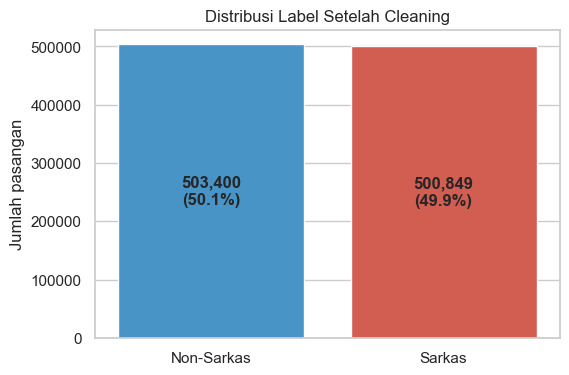

In [129]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x="label_name", hue="label_name", palette=PALETTE, legend=False)
for p in ax.patches:
    h = p.get_height()
    ax.annotate(f"{int(h):,}\n({h / len(df):.1%})", (p.get_x() + p.get_width() / 2, h / 2),
                ha="center", va="center", fontweight="bold")
plt.title("Distribusi Label Setelah Cleaning")
plt.xlabel("")
plt.ylabel("Jumlah pasangan")
save_fig("01_label_distribution")
plt.show()

#### A. Analisis yang terlihat
- Kedua batang grafik menunjukkan proporsi yang hampir sama persis: Non-Sarkas 503.400 dan Sarkas 500.849.

#### B. Analisis data science:
- Dataset ini adalah Balanced Dataset (seimbang).
- Model machine learning/deep learning nantinya tidak akan memiliki bias ke salah satu kelas. Tidak perlu repot melakukan teknik penyeimbangan data seperti oversampling (SMOTE) atau undersampling.
- Aman menggunakan metrik Accuracy sebagai salah satu metrik utama, di samping F1-Score, Precision, dan Recall.

### 4.2 Distribusi Panjang Karakter dan Jumlah Kata per Komentar

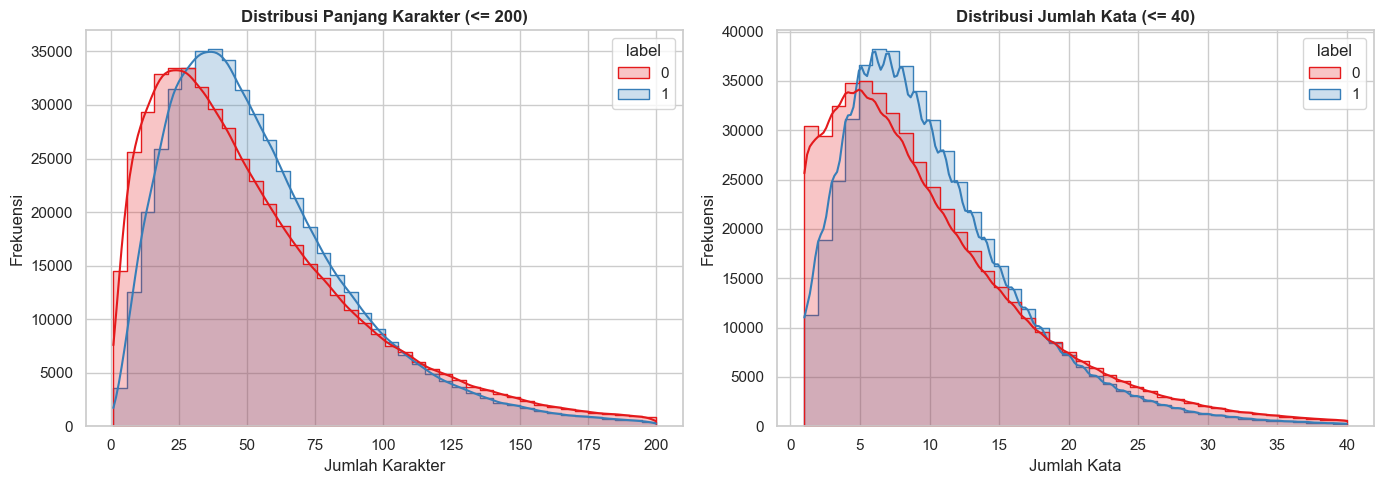

In [130]:
df['char_length'] = df['comment'].astype(str).apply(len)
df['word_count'] = df['comment'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df[df['char_length'] <= 200], x='char_length', hue='label', 
             kde=True, bins=40, palette='Set1', ax=axes[0], element='step')
axes[0].set_title('Distribusi Panjang Karakter (<= 200)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Jumlah Karakter')
axes[0].set_ylabel('Frekuensi')

sns.histplot(data=df[df['word_count'] <= 40], x='word_count', hue='label', 
             kde=True, bins=40, palette='Set1', ax=axes[1], element='step')
axes[1].set_title('Distribusi Jumlah Kata (<= 40)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Jumlah Kata')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

#### A. Analisis yang terlihat:
- Bentuk kurvanya condong ke kiri dan berekor panjang ke kanan (right-skewed). Sebagian besar komentar Reddit sangat ringkas: rata-rata 30–80 karakter atau sekitar 5–15 kata.
- Kurva komentar sarkas (biru) dan non-sarkas saling bertumpuk (overlap) hampir identik.

#### B. Analisis Data Science:
- Panjang teks bukan pembeda yang signifikan: Kita tidak bisa menebak kalimat itu sarkas atau tidak hanya dari panjang-pendeknya kalimat. Kalimat sarkas ada yang sangat pendek (misal: "brilliant idea.") dan ada juga yang panjang.
- Efisiensi Training Model (Penting!): Karena >95% komentar memiliki panjang di bawah 40 kata (atau ~150 karakter), saat melatih model Deep Learning/Transformer (seperti BERT atau RoBERTa), cukup mematok max_length = 64 atau max_length = 128. Ini akan menghemat memori GPU/RAM dan mempercepat waktu training hingga 2–3x lipat tanpa memotong informasi penting.

> **Catatan:** rekomendasi `max_length = 64/128` di atas dihitung dari jumlah kata comment saja. Input model pada proposal adalah pasangan **parent + comment** dalam satuan token, dan panjang yang digunakan adalah **256 token**. Lihat bagian **7.1**.

### 4.3 Distribusi Top 15 Subreddit Paling Banyak Komentar

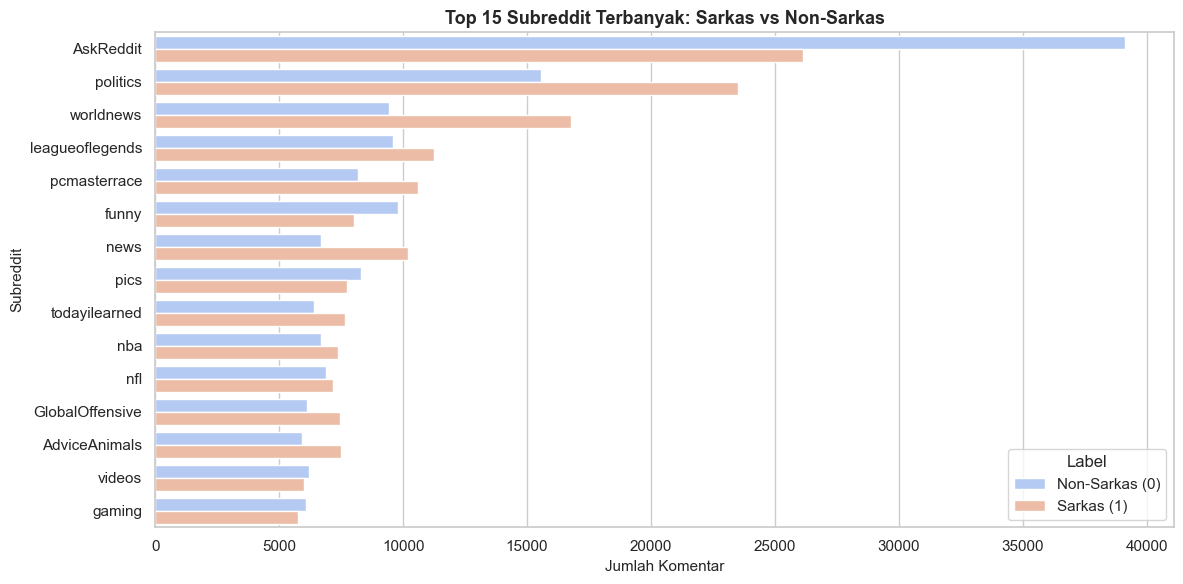

In [131]:
top_subreddits = df['subreddit'].value_counts().nlargest(15).index
df_top_sub = df[df['subreddit'].isin(top_subreddits)]

plt.figure(figsize=(12, 6))
sns.countplot(y='subreddit', hue='label', data=df_top_sub, 
              order=top_subreddits, palette='coolwarm')
plt.title('Top 15 Subreddit Terbanyak: Sarkas vs Non-Sarkas', fontsize=13, fontweight='bold')
plt.xlabel('Jumlah Komentar', fontsize=11)
plt.ylabel('Subreddit', fontsize=11)
plt.legend(title='Label', labels=['Non-Sarkas (0)', 'Sarkas (1)'])
plt.tight_layout()
plt.show()

#### Analisis yang terlihat:
- Komentar paling banyak berasal dari komunitas diskusi umum/opini (AskReddit, politics, worldnews) dan komunitas hobi/gaming (leagueoflegends, pcmasterrace, nba, nfl).
- Di hampir semua subreddit besar ini, rasio antara komentar sarkas dan non-sarkas relatif seimbang dan sama-sama tinggi.

#### Analisis data science:
- Sarkasme sangat terikat dengan "Konteks Komunitas": Gaya bahasa sarkastik di subreddit politics sangat berbeda dengan gaya sarkastik di leagueoflegends atau AskReddit.
- Ide Nilai Tambah untuk TA: Kalimat yang sama bisa berarti pujian tulus di satu subreddit, namun bermakna sarkas di subreddit lain. Jika ingin meningkatkan performa model, bisa mencoba Hybrid Model (menggabungkan input teks komentar dengan fitur nama subreddit).

### 4.4 Distribusi Skor Reddit (score) Berdasarkan Label

/var/folders/qk/vt03qgxx57d2nf96qtx8rwpr0000gn/T/ipykernel_3056/1456893267.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='score', data=df[(df['score'] >= -10) & (df['score'] <= 50)], palette='Pastel1')


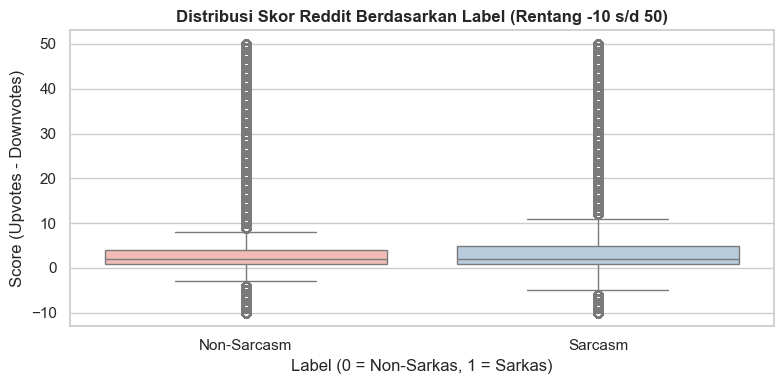

In [132]:
plt.figure(figsize=(8, 4))

sns.boxplot(x='label', y='score', data=df[(df['score'] >= -10) & (df['score'] <= 50)], palette='Pastel1')
plt.title('Distribusi Skor Reddit Berdasarkan Label (Rentang -10 s/d 50)', fontsize=12, fontweight='bold')
plt.xlabel('Label (0 = Non-Sarkas, 1 = Sarkas)')
plt.ylabel('Score (Upvotes - Downvotes)')
plt.xticks([0, 1], ['Non-Sarcasm', 'Sarcasm'])
plt.tight_layout()
plt.show()

#### Analisis yang terlihat:
- Titik tengah (median) skor untuk komentar sarkas dan non-sarkas sama-sama berada di angka yang relatif rendah (mendekati 0 hingga 2).
- Kotak persebarannya (interquartile range) terlihat mirip.

#### Analisis data science
- Komentar sarkastik di Reddit tidak serta-merta mendapat respons negatif (downvote). Faktanya, banyak komentar sarkas yang justru dianggap lucu, cerdas, atau menghibur sehingga mendapat skor positif yang mirip dengan komentar normal.
- Skor saja tidak bisa dijadikan fitur tunggal yang kuat untuk klasifikasi, namun bisa menjadi fitur pendukung (metadata) bersama konteks waktu dan parent comment.

### 4.5 Popularitas Komentar Berdasarkan Sarkasme

In [133]:
# Converting the scores into numpy array
sarcasm_score = np.array(df.loc[df['label'] == 1]['score'])
neutral_score = np.array(df.loc[df['label'] == 0]['score'])

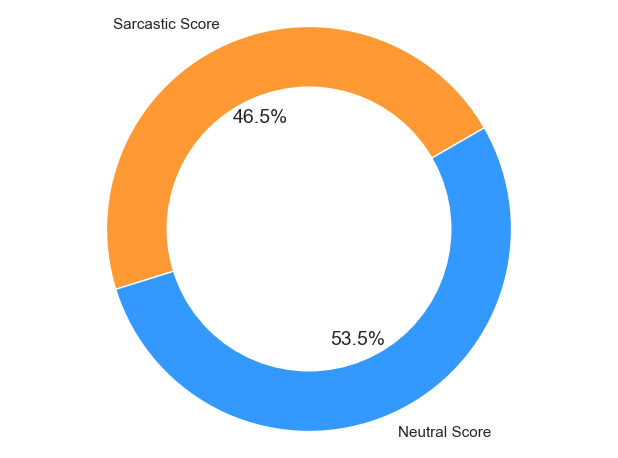

In [134]:
# Menampilkan perbandingan proporsi komentar Sarkas vs Netral di Reddit
labels = ['Sarcastic Score', 'Neutral Score']
sizes = [3235069, 3725113]

# Menggunakan warna netral (Oranye dan Biru) agar pembaca tidak bias
colors = ['#FF9933', '#3399FF']
 
plt.rcParams.update({'font.size': 14})
fig1, ax1 = plt.subplots()

# Membuat Pie Chart
ax1.pie(sizes, colors=colors, labels=labels, autopct='%1.1f%%', startangle=30)

# Membuat lingkaran putih di tengah (Donut Chart)
centre_circle = plt.Circle((0,0), 0.70, fc='white')

# Langsung menempelkan lingkaran ke ax1 (Lebih rapi, aman, dan efisien)
ax1.add_artist(centre_circle)

# Memastikan bentuk grafik bulat sempurna
ax1.axis('equal') 
plt.tight_layout()
plt.show()

> **Catatan:** nilai `sizes` pada donut chart ditulis manual dan merupakan jumlah total `score` per kelas. Karena `score` bisa bernilai negatif, perbandingan popularitas lebih tepat dilihat dari median dan sebaran pada bagian **4.4**.

#### Insight:
popularitas komentar sarcastic dan non-sarcastic perlu dibandingkan melalui median serta penyebaran distribusinya. Apabila komentar sarcastic memiliki median score yang lebih tinggi, dapat dikatakan bahwa unsur sarkasme berpotensi meningkatkan engagement. Namun, jika perbedaannya kecil dan distribusinya banyak bertumpang tindih, pengaruh sarkasme terhadap popularitas kemungkinan tidak dominan.

### 4.6 Sarkasme Berdasarkan Hari dalam Seminggu

In [135]:
# Salin dataframe agar data asli tetap aman
analysis_df = df.copy()

# Konversi tanggal secara lebih aman
analysis_df["created_utc"] = pd.to_datetime(
    analysis_df["created_utc"],
    dayfirst=True,
    errors="coerce"
)

# Hapus baris dengan tanggal atau label yang tidak valid
analysis_df = analysis_df.dropna(
    subset=["created_utc", "label"]
).copy()

# Ekstraksi nama hari
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

analysis_df["day_of_week"] = pd.Categorical(
    analysis_df["created_utc"].dt.day_name(),
    categories=day_order,
    ordered=True
)

# Statistik per hari
daily_summary = (
    analysis_df
    .groupby("day_of_week", observed=False)
    .agg(
        total_comments=("label", "size"),
        sarcastic_comments=("label", "sum")
    )
    .reset_index()
)

daily_summary["non_sarcastic_comments"] = (
    daily_summary["total_comments"] -
    daily_summary["sarcastic_comments"]
)

# Persentase sarcastic dari seluruh komentar pada hari tersebut
daily_summary["sarcasm_rate"] = (
    daily_summary["sarcastic_comments"] /
    daily_summary["total_comments"] * 100
)

# Persentase kontribusi tiap hari terhadap seluruh komentar sarcastic
total_sarcastic = daily_summary["sarcastic_comments"].sum()

daily_summary["share_of_all_sarcastic"] = (
    daily_summary["sarcastic_comments"] /
    total_sarcastic * 100
)

display(daily_summary.round(2))

/var/folders/qk/vt03qgxx57d2nf96qtx8rwpr0000gn/T/ipykernel_3056/3248163133.py:5: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  analysis_df["created_utc"] = pd.to_datetime(


,day_of_week,total_comments,sarcastic_comments,non_sarcastic_comments,sarcasm_rate,share_of_all_sarcastic
0,Monday,145464,72817,72647,50.06,14.54
1,Tuesday,152541,76954,75587,50.45,15.36
2,Wednesday,155470,78069,77401,50.21,15.59
3,Thursday,154460,77596,76864,50.24,15.49
4,Friday,148847,74075,74772,49.77,14.79
5,Saturday,121785,59457,62328,48.82,11.87
6,Sunday,125682,61881,63801,49.24,12.36


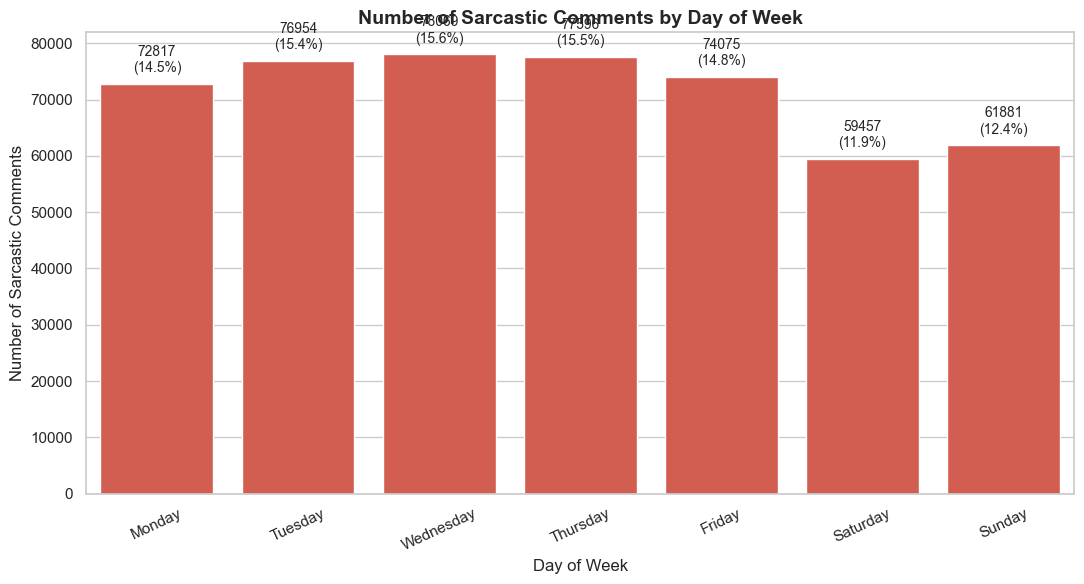

In [136]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=daily_summary,
    x="day_of_week",
    y="sarcastic_comments",
    order=day_order,
    color="#E74C3C"
)

plt.title(
    "Number of Sarcastic Comments by Day of Week",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Day of Week")
plt.ylabel("Number of Sarcastic Comments")
plt.xticks(rotation=25)

# Tambahkan jumlah dan persentase kontribusi
for i, row in daily_summary.iterrows():
    ax.text(
        i,
        row["sarcastic_comments"] + daily_summary["sarcastic_comments"].max() * 0.02,
        f'{int(row["sarcastic_comments"])}\n'
        f'({row["share_of_all_sarcastic"]:.1f}%)',
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

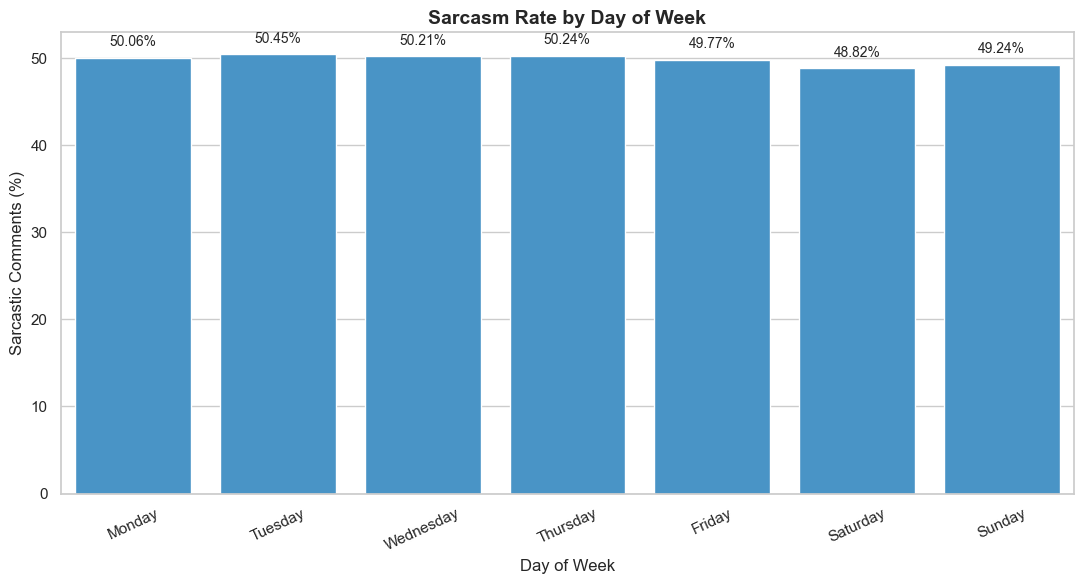

In [137]:
plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=daily_summary,
    x="day_of_week",
    y="sarcasm_rate",
    order=day_order,
    color="#3498DB"
)

plt.title(
    "Sarcasm Rate by Day of Week",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Day of Week")
plt.ylabel("Sarcastic Comments (%)")
plt.xticks(rotation=25)

for i, row in daily_summary.iterrows():
    ax.text(
        i,
        row["sarcasm_rate"] + daily_summary["sarcasm_rate"].max() * 0.02,
        f'{row["sarcasm_rate"]:.2f}%',
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

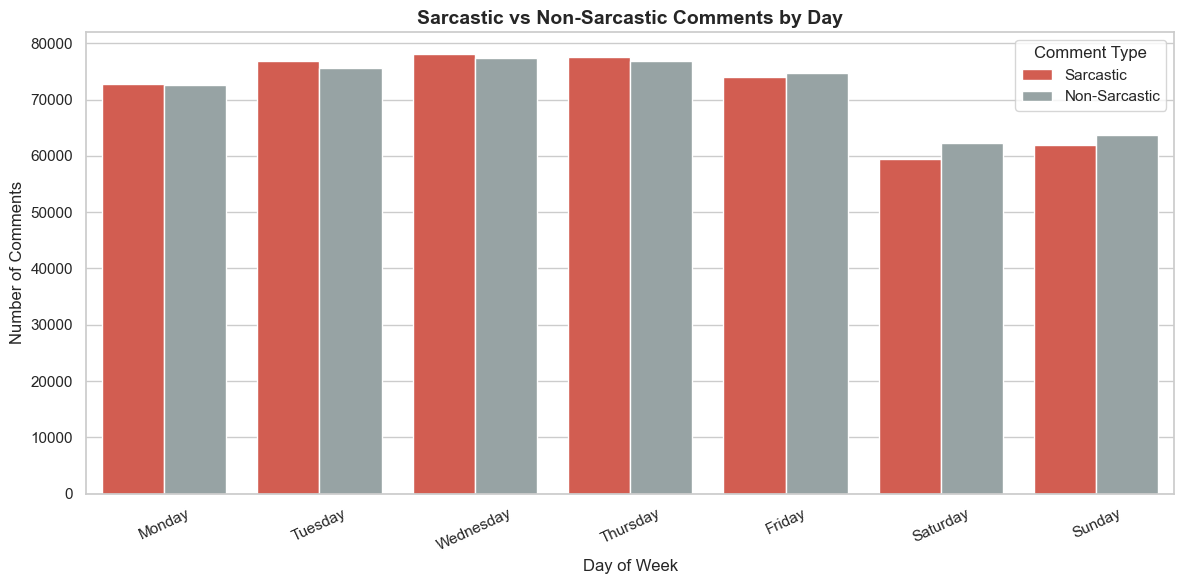

In [138]:
plot_df = daily_summary[
    [
        "day_of_week",
        "sarcastic_comments",
        "non_sarcastic_comments"
    ]
].melt(
    id_vars="day_of_week",
    var_name="comment_type",
    value_name="count"
)

plot_df["comment_type"] = plot_df["comment_type"].replace({
    "sarcastic_comments": "Sarcastic",
    "non_sarcastic_comments": "Non-Sarcastic"
})

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=plot_df,
    x="day_of_week",
    y="count",
    hue="comment_type",
    order=day_order,
    palette={
        "Sarcastic": "#E74C3C",
        "Non-Sarcastic": "#95A5A6"
    }
)

plt.title(
    "Sarcastic vs Non-Sarcastic Comments by Day",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Day of Week")
plt.ylabel("Number of Comments")
plt.xticks(rotation=25)
plt.legend(title="Comment Type")

plt.tight_layout()
plt.show()

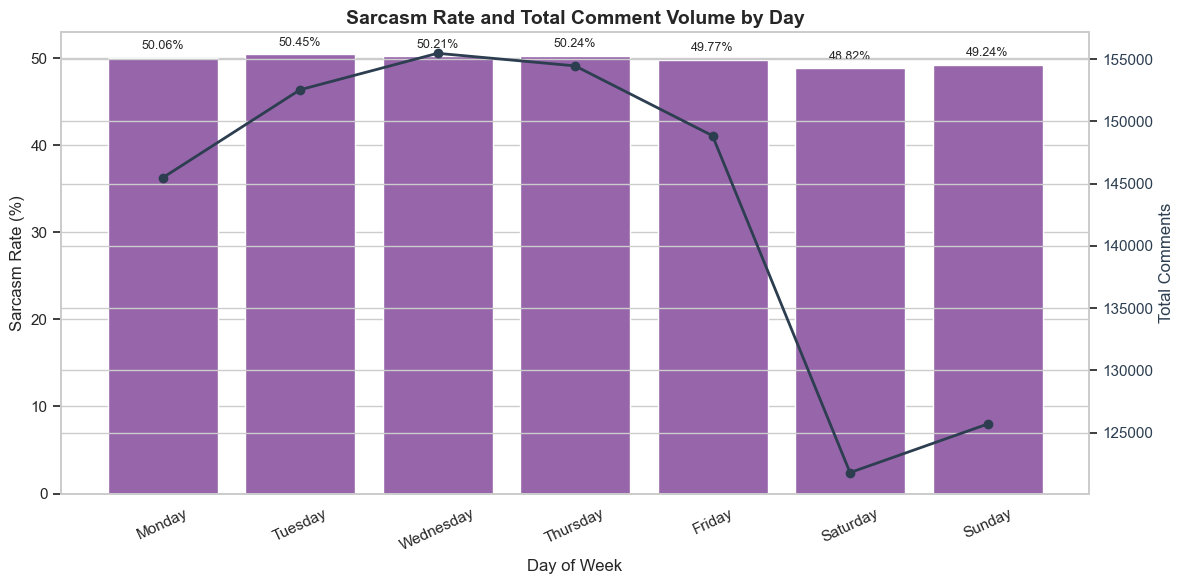

In [139]:
fig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=daily_summary,
    x="day_of_week",
    y="sarcasm_rate",
    order=day_order,
    color="#9B59B6",
    ax=ax1
)

ax1.set_title(
    "Sarcasm Rate and Total Comment Volume by Day",
    fontsize=14,
    fontweight="bold"
)
ax1.set_xlabel("Day of Week")
ax1.set_ylabel("Sarcasm Rate (%)")
ax1.tick_params(axis="x", rotation=25)

for i, row in daily_summary.iterrows():
    ax1.text(
        i,
        row["sarcasm_rate"] + daily_summary["sarcasm_rate"].max() * 0.02,
        f'{row["sarcasm_rate"]:.2f}%',
        ha="center",
        fontsize=9
    )

# Sumbu kedua untuk jumlah komentar
ax2 = ax1.twinx()

ax2.plot(
    range(len(daily_summary)),
    daily_summary["total_comments"],
    color="#2C3E50",
    marker="o",
    linewidth=2,
    label="Total Comments"
)

ax2.set_ylabel("Total Comments", color="#2C3E50")
ax2.tick_params(axis="y", labelcolor="#2C3E50")

plt.tight_layout()
plt.show()

In [140]:
highest_rate_day = daily_summary.loc[
    daily_summary["sarcasm_rate"].idxmax()
]

lowest_rate_day = daily_summary.loc[
    daily_summary["sarcasm_rate"].idxmin()
]

print(
    f"Hari dengan sarcasm rate tertinggi: "
    f"{highest_rate_day['day_of_week']} "
    f"({highest_rate_day['sarcasm_rate']:.2f}%)"
)

print(
    f"Hari dengan sarcasm rate terendah: "
    f"{lowest_rate_day['day_of_week']} "
    f"({lowest_rate_day['sarcasm_rate']:.2f}%)"
)

Hari dengan sarcasm rate tertinggi: Tuesday (50.45%)
Hari dengan sarcasm rate terendah: Saturday (48.82%)


#### Insight:

Pola sarkasme relatif konsisten sepanjang minggu, dengan sekitar setengah komentar pada setiap hari diklasifikasikan sebagai sarkastik. Selasa memiliki tingkat sarkasme tertinggi sebesar 50,57%, sedangkan Sabtu terendah sebesar 48,95%. Akan tetapi, selisih antarhari sangat kecil, sehingga hari dalam minggu tampaknya bukan faktor utama yang menentukan apakah seseorang membuat komentar sarkastik. Perbedaan yang lebih jelas justru terlihat pada volume komentar: aktivitas percakapan jauh lebih tinggi pada hari kerja dibandingkan akhir pekan.

## 5. Analisis Leksikal

### 5.1 WordCloud

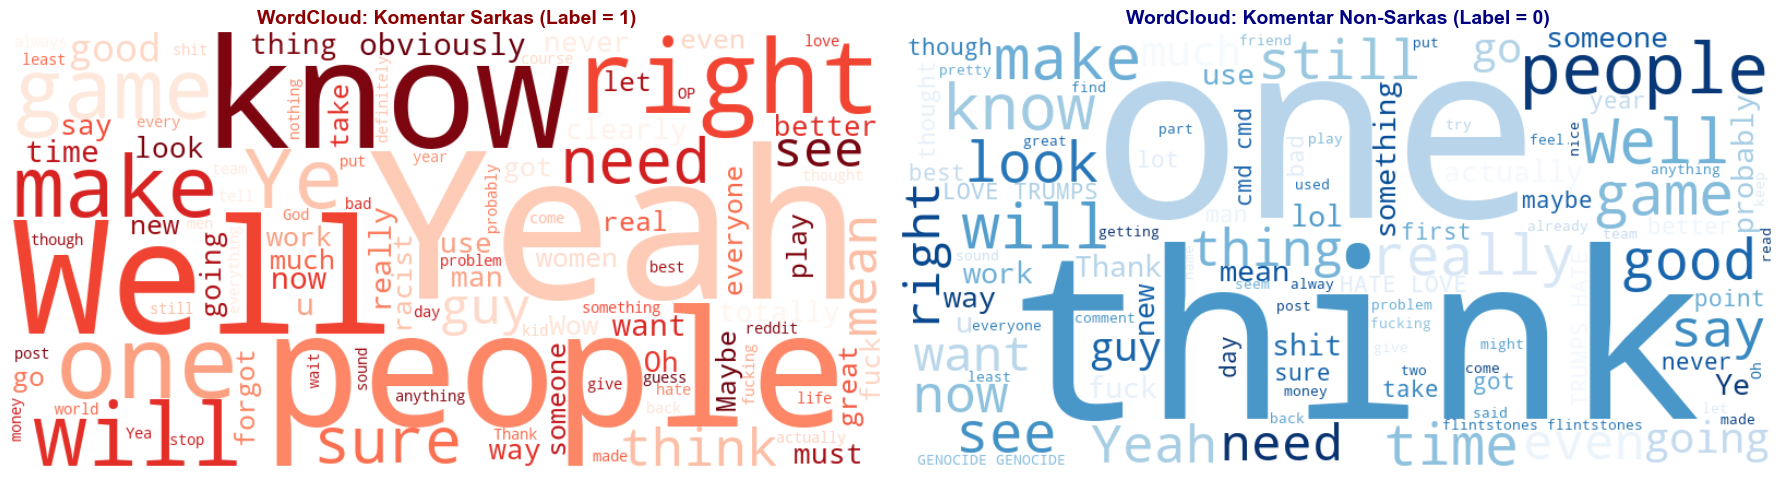

In [141]:
sample_sarcasm = df[df['label'] == 1]['comment'].sample(50000, random_state=42).astype(str)
sample_non_sarcasm = df[df['label'] == 0]['comment'].sample(50000, random_state=42).astype(str)

text_sarcasm = " ".join(sample_sarcasm)
text_non_sarcasm = " ".join(sample_non_sarcasm)

stopwords = set(STOPWORDS)

wc_sarcasm = WordCloud(width=800, height=400, background_color='white',
                       stopwords=stopwords, max_words=100, colormap='Reds').generate(text_sarcasm)

wc_non_sarcasm = WordCloud(width=800, height=400, background_color='white',
                           stopwords=stopwords, max_words=100, colormap='Blues').generate(text_non_sarcasm)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].imshow(wc_sarcasm, interpolation='bilinear')
axes[0].set_title('WordCloud: Komentar Sarkas (Label = 1)', fontsize=14, fontweight='bold', color='darkred')
axes[0].axis('off')

axes[1].imshow(wc_non_sarcasm, interpolation='bilinear')
axes[1].set_title('WordCloud: Komentar Non-Sarkas (Label = 0)', fontsize=14, fontweight='bold', color='navy')
axes[1].axis('off')

plt.tight_layout()
plt.show()

#### Analisis yang terlihat:
- **Kata Dominan Komentar Sarkas (Label 1):** Sering memuat kata-kata persetujuan yang bernada melebih-lebihkan (*obviously*, *yeah*, *yes*, *sure*, *clearly*) serta kata bernuansa positif semu (*good*, *better*, *right*).
- **Kata Dominan Komentar Non-Sarkas (Label 0):** Cenderung berupa kata-kata deskriptif dan netral yang umum digunakan dalam diskusi santai di Reddit (*people*, *game*, *time*, *look*, *much*, *way*, *year*).
- **Tingginya Tumpang Tindih Kosakata (*Vocabulary Overlap*):** Kata-kata umum seperti *people*, *think*, *know*, *good*, dan *make* muncul dengan ukuran besar di kedua kelas.

#### Analisis Data Science:
- **Kelemahan Model Berbasis Kata Tunggal (*Bag of Words*):** Kemiripan kosakata di kedua kelas menunjukkan bahwa frekuensi kata per kata saja tidak cukup untuk membedakan sarkasme.
- **Ironi Sentimen Positif Semu (*Pseudo-Positive*):** Kata-kata positif (*good*, *great*) pada komentar sarkas dipakai secara kontradiktif untuk menyindir. Model berbasis kamus leksikon (*lexicon-based*) akan mudah terkecoh jika hanya melihat sentimen kata perkata.
- **Justifikasi Pemodelan Kontekstual:** Hasil ini memperkuat alasan bahwa model NLP yang akan digunakan harus mampu memahami **konteks kalimat dan urutan kata** (misalnya TF-IDF dengan N-Gram, LSTM, atau Transformer seperti BERT/RoBERTa) dibanding sekadar model berbasis kata tunggal (*unigram*).

### 5.2 Bi-gram & Tri-gram

/var/folders/qk/vt03qgxx57d2nf96qtx8rwpr0000gn/T/ipykernel_3056/3508795767.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='ngram', data=top_bi_sarcasm, ax=axes[0, 0], palette='Reds_r')
/var/folders/qk/vt03qgxx57d2nf96qtx8rwpr0000gn/T/ipykernel_3056/3508795767.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='ngram', data=top_bi_non_sarcasm, ax=axes[0, 1], palette='Blues_r')
/var/folders/qk/vt03qgxx57d2nf96qtx8rwpr0000gn/T/ipykernel_3056/3508795767.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='cou

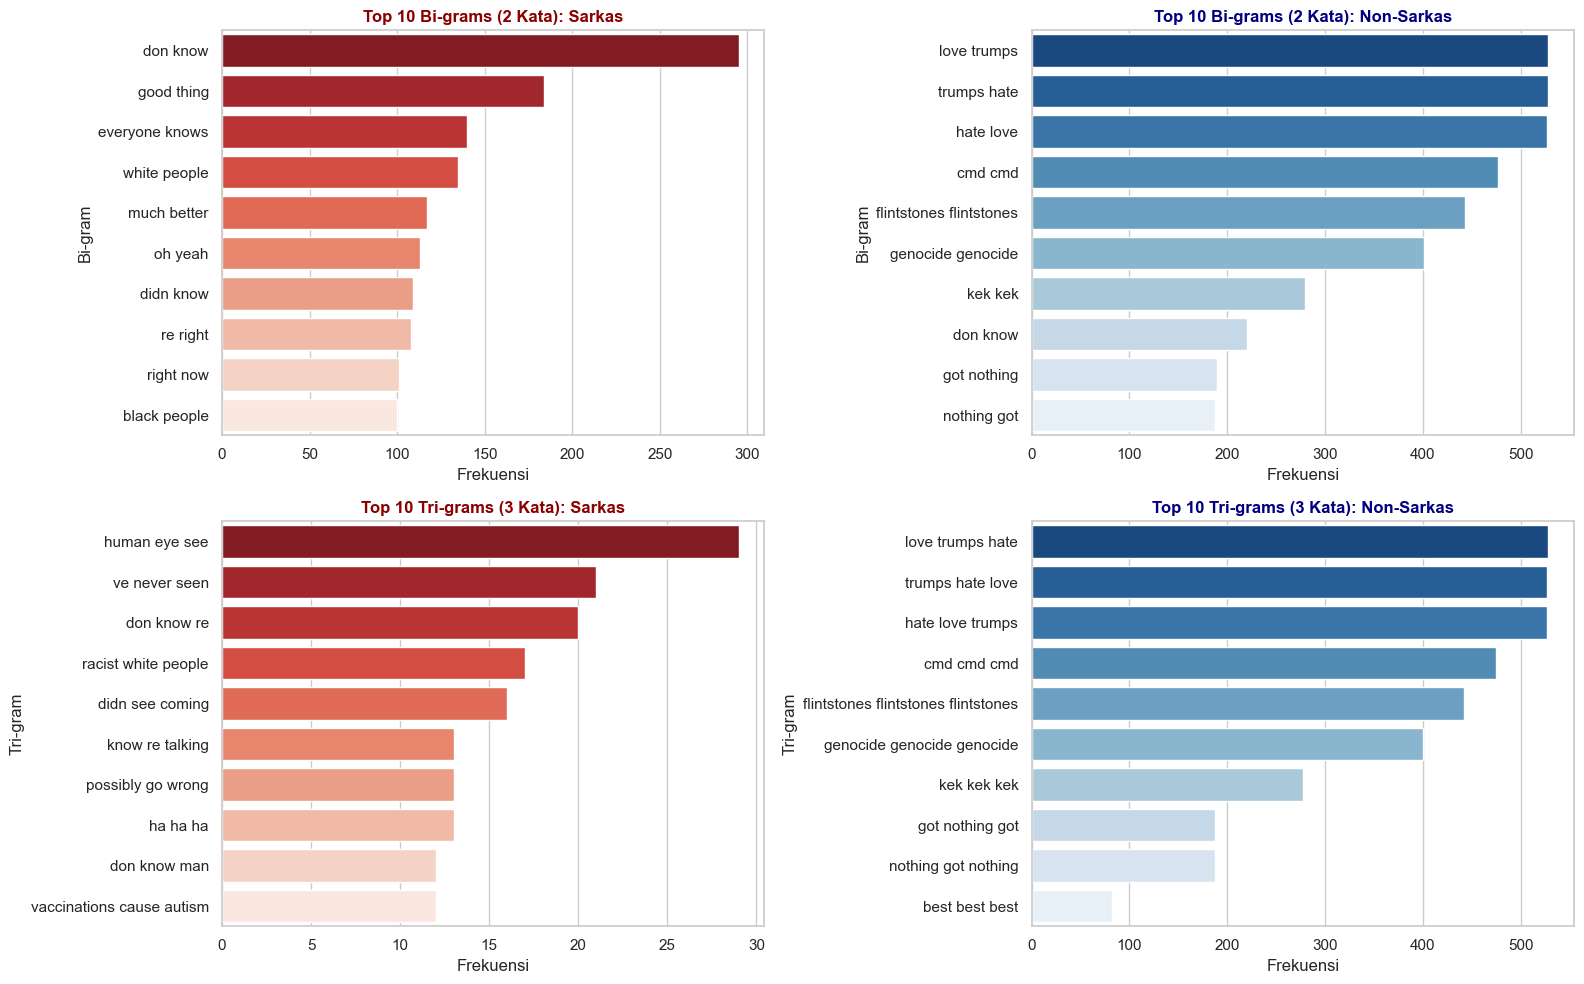

In [142]:
# 1. Fungsi ekstraksi N-Gram murni Python (tanpa dependency scipy/sklearn)
def get_top_ngrams_native(corpus, n=2, top_k=10, stopwords=STOPWORDS):
    counter = Counter()
    for text in corpus:
        # Tokenisasi kata (hanya huruf, huruf kecil, abaikan stopwords)
        tokens = [w for w in re.findall(r'\b[a-zA-Z]+\b', str(text).lower()) 
                  if w not in stopwords and len(w) > 1]
        
        # Bentuk pasangan n-gram
        if len(tokens) >= n:
            ngrams = [' '.join(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]
            counter.update(ngrams)
            
    return pd.DataFrame(counter.most_common(top_k), columns=['ngram', 'count'])

# 2. Ambil sampel 50.000 data per kelas
sample_sarcasm = df[df['label'] == 1]['comment'].sample(50000, random_state=42).astype(str)
sample_non_sarcasm = df[df['label'] == 0]['comment'].sample(50000, random_state=42).astype(str)

# 3. Ekstraksi Top 10 Bi-grams (2 kata) & Tri-grams (3 kata)
top_bi_sarcasm = get_top_ngrams_native(sample_sarcasm, n=2, top_k=10)
top_bi_non_sarcasm = get_top_ngrams_native(sample_non_sarcasm, n=2, top_k=10)

top_tri_sarcasm = get_top_ngrams_native(sample_sarcasm, n=3, top_k=10)
top_tri_non_sarcasm = get_top_ngrams_native(sample_non_sarcasm, n=3, top_k=10)

# 4. Visualisasi Grid 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Barplot Bi-gram Sarkas
sns.barplot(x='count', y='ngram', data=top_bi_sarcasm, ax=axes[0, 0], palette='Reds_r')
axes[0, 0].set_title('Top 10 Bi-grams (2 Kata): Sarkas', fontsize=12, fontweight='bold', color='darkred')
axes[0, 0].set_xlabel('Frekuensi')
axes[0, 0].set_ylabel('Bi-gram')

# Barplot Bi-gram Non-Sarkas
sns.barplot(x='count', y='ngram', data=top_bi_non_sarcasm, ax=axes[0, 1], palette='Blues_r')
axes[0, 1].set_title('Top 10 Bi-grams (2 Kata): Non-Sarkas', fontsize=12, fontweight='bold', color='navy')
axes[0, 1].set_xlabel('Frekuensi')
axes[0, 1].set_ylabel('Bi-gram')

# Barplot Tri-gram Sarkas
sns.barplot(x='count', y='ngram', data=top_tri_sarcasm, ax=axes[1, 0], palette='Reds_r')
axes[1, 0].set_title('Top 10 Tri-grams (3 Kata): Sarkas', fontsize=12, fontweight='bold', color='darkred')
axes[1, 0].set_xlabel('Frekuensi')
axes[1, 0].set_ylabel('Tri-gram')

# Barplot Tri-gram Non-Sarkas
sns.barplot(x='count', y='ngram', data=top_tri_non_sarcasm, ax=axes[1, 1], palette='Blues_r')
axes[1, 1].set_title('Top 10 Tri-grams (3 Kata): Non-Sarkas', fontsize=12, fontweight='bold', color='navy')
axes[1, 1].set_xlabel('Frekuensi')
axes[1, 1].set_ylabel('Tri-gram')

plt.tight_layout()
plt.show()

#### Visualisasi
1. Sarkasme lebih sering menggunakan pola afirmasi berlebihan dan kontras makna, seperti good thing, oh yeah, much better, dan makes perfect sense.
2. Frekuensi n-gram biasa belum cukup untuk menemukan ciri sarkasme yang kuat, karena beberapa frasa muncul pada kedua kelas.
3. Kelas non-sarkas memiliki indikasi kuat adanya duplikasi, spam, atau artefak topik, terutama pada comcast dan islam.
4. Model berbasis TF-IDF sebaiknya menggunakan word n-gram dengan ngram_range=(1, 3), tetapi perlu dilengkapi dengan:
    - penghapusan komentar duplikat,
    - pemeriksaan komentar sangat pendek,
    - analisis log odds ratio atau chi-square,
    - validasi agar model tidak hanya menghafal topik seperti comcast atau islam.

## 6. Analisis Konteks Comment–Parent

Sarkasme sangat bergantung pada konteks percakapan, sehingga hubungan antara *comment* dan *parent comment* dianalisis dari tiga sudut:
- **Panjang**: apakah comment merupakan balasan singkat terhadap parent yang panjang?
- **Kemiripan leksikal**: apakah comment mengulang kata-kata parent?
- **Kontras sentimen**: apakah parent bernada negatif dibalas comment yang terdengar positif?

Fitur dihitung dari sampel 25.000 pasangan per label.

### 6.1 Panjang Sarcastic Comment vs Parent Comment

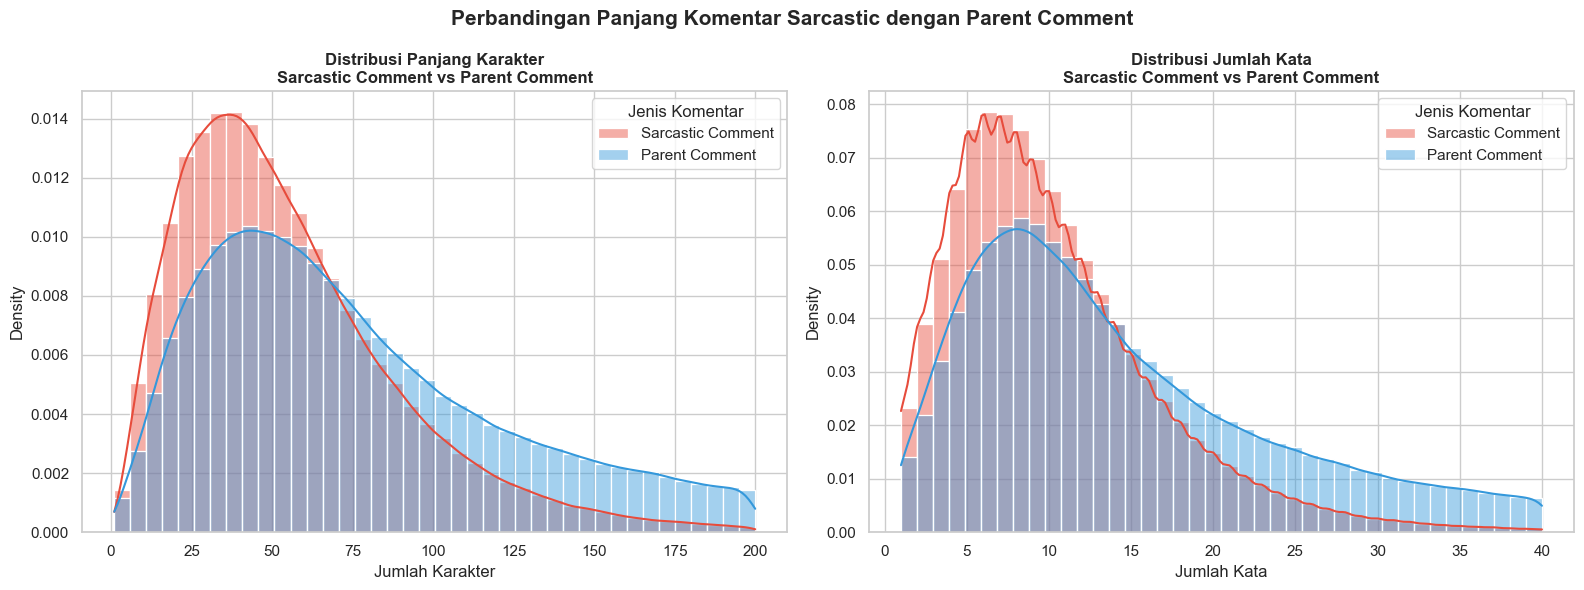

In [143]:
# Ambil hanya komentar sarcastic
sarcastic_df = df[df["label"] == 1].copy()

# Pastikan nilai kosong tidak menghasilkan error
sarcastic_df["comment"] = sarcastic_df["comment"].fillna("").astype(str)
sarcastic_df["parent_comment"] = (
    sarcastic_df["parent_comment"]
    .fillna("")
    .astype(str)
)

# Hitung panjang berdasarkan karakter
sarcastic_df["comment_char_length"] = sarcastic_df["comment"].str.len()
sarcastic_df["parent_char_length"] = sarcastic_df["parent_comment"].str.len()

# Hitung panjang berdasarkan jumlah kata
sarcastic_df["comment_word_count"] = (
    sarcastic_df["comment"].str.split().str.len()
)

sarcastic_df["parent_word_count"] = (
    sarcastic_df["parent_comment"].str.split().str.len()
)

# Batasi nilai ekstrem agar pola distribusi lebih mudah terlihat
char_limit = 200
word_limit = 40

comment_char = sarcastic_df[
    sarcastic_df["comment_char_length"] <= char_limit
]["comment_char_length"]

parent_char = sarcastic_df[
    sarcastic_df["parent_char_length"] <= char_limit
]["parent_char_length"]

comment_words = sarcastic_df[
    sarcastic_df["comment_word_count"] <= word_limit
]["comment_word_count"]

parent_words = sarcastic_df[
    sarcastic_df["parent_word_count"] <= word_limit
]["parent_word_count"]

# Pengaturan visual
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Visualisasi jumlah karakter
sns.histplot(
    comment_char,
    bins=40,
    kde=True,
    stat="density",
    color="#E74C3C",
    alpha=0.45,
    edgecolor="white",
    label="Sarcastic Comment",
    ax=axes[0]
)

sns.histplot(
    parent_char,
    bins=40,
    kde=True,
    stat="density",
    color="#3498DB",
    alpha=0.45,
    edgecolor="white",
    label="Parent Comment",
    ax=axes[0]
)

axes[0].set_title(
    "Distribusi Panjang Karakter\nSarcastic Comment vs Parent Comment",
    fontsize=12,
    fontweight="bold"
)
axes[0].set_xlabel("Jumlah Karakter")
axes[0].set_ylabel("Density")
axes[0].legend(title="Jenis Komentar")

# Visualisasi jumlah kata
sns.histplot(
    comment_words,
    bins=40,
    kde=True,
    stat="density",
    color="#E74C3C",
    alpha=0.45,
    edgecolor="white",
    label="Sarcastic Comment",
    ax=axes[1]
)

sns.histplot(
    parent_words,
    bins=40,
    kde=True,
    stat="density",
    color="#3498DB",
    alpha=0.45,
    edgecolor="white",
    label="Parent Comment",
    ax=axes[1]
)

axes[1].set_title(
    "Distribusi Jumlah Kata\nSarcastic Comment vs Parent Comment",
    fontsize=12,
    fontweight="bold"
)
axes[1].set_xlabel("Jumlah Kata")
axes[1].set_ylabel("Density")
axes[1].legend(title="Jenis Komentar")

plt.suptitle(
    "Perbandingan Panjang Komentar Sarcastic dengan Parent Comment",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

#### Insight:
1. Komentar sarcastic cenderung lebih pendek daripada parent comment apabila distribusi sarcastic comment lebih banyak berada di sebelah kiri atau memiliki median yang lebih kecil. Ini menunjukkan bahwa sarkasme sering disampaikan secara singkat sebagai respons, sindiran, atau punchline terhadap konteks yang sudah tersedia pada parent comment.

2. Parent comment biasanya memberikan konteks yang lebih panjang. Komentar sarcastic tidak selalu perlu menjelaskan latar belakang secara lengkap karena maknanya bergantung pada isi parent comment.

3. Jika distribusi kedua kurva saling overlap, panjang teks bukan faktor utama yang membedakan komentar sarcastic dari parent comment. Artinya, komentar sarcastic bisa memiliki panjang yang mirip dengan parent comment, sehingga fitur panjang saja belum cukup untuk mendeteksi sarkasme.

4. Jika terdapat ekor distribusi yang panjang, berarti terdapat beberapa komentar dengan panjang ekstrem. Nilai rata-rata dapat terpengaruh oleh komentar-komentar tersebut, sehingga median lebih tepat digunakan sebagai ukuran pembanding.

5. Perbedaan jumlah karakter dan jumlah kata dapat memberikan informasi berbeda. Jumlah karakter dapat dipengaruhi oleh tanda baca, emoji, atau penggunaan kata yang panjang, sedangkan jumlah kata lebih menggambarkan panjang isi komentar secara linguistik.


#### Kesimpulan:
Distribusi panjang sarcastic comment dibandingkan dengan parent comment menunjukkan bahwa komentar sarcastic cenderung lebih ringkas dan berfungsi sebagai respons terhadap konteks yang telah diberikan oleh parent comment. Hal ini mengindikasikan bahwa sarkasme tidak selalu membutuhkan penjelasan yang panjang, melainkan dapat disampaikan melalui kalimat singkat yang mengandung ironi atau sindiran. Namun, adanya area distribusi yang saling tumpang tindih menunjukkan bahwa panjang komentar saja belum cukup untuk mengidentifikasi sarkasme. Fitur lain seperti sentimen, tanda baca, kata-kata intensifier, emoji, dan konteks parent comment kemungkinan diperlukan untuk analisis yang lebih akurat.

### 6.2 Fitur Pasangan Comment–Parent

In [144]:
ctx = df.groupby("label", group_keys=False).sample(25_000, random_state=SEED).reset_index(drop=True)

# 1) Panjang
ctx["len_comment"] = ctx["comment_clean"].str.split().str.len()
ctx["len_parent"] = ctx["parent_clean"].str.split().str.len()
ctx["len_ratio"] = ctx["len_comment"] / ctx["len_parent"]

# 2) Kemiripan leksikal: cosine TF-IDF per pasangan + proporsi kata comment yang ada di parent
tfidf = TfidfVectorizer(min_df=2).fit(pd.concat([ctx["comment_clean"], ctx["parent_clean"]]))
C = tfidf.transform(ctx["comment_clean"])
P = tfidf.transform(ctx["parent_clean"])
ctx["cosine_sim"] = np.asarray(C.multiply(P).sum(axis=1)).ravel()   # baris sudah ter-normalisasi L2

def overlap(c, p):
    c, p = set(c.split()), set(p.split())
    return len(c & p) / len(c)
ctx["word_overlap"] = [overlap(c, p) for c, p in zip(ctx["comment_clean"], ctx["parent_clean"])]

# 3) Sentimen (VADER pakai teks asli, karena VADER butuh tanda baca & kapital; ini hanya untuk EDA)
vader = SentimentIntensityAnalyzer()
ctx["sent_comment"] = [vader.polarity_scores(t)["compound"] for t in ctx["comment"]]
ctx["sent_parent"] = [vader.polarity_scores(t)["compound"] for t in ctx["parent_comment"]]
ctx["sent_gap"] = (ctx["sent_comment"] - ctx["sent_parent"]).abs()

#### Penjelasan Fitur

Semua fitur dihitung per pasangan (comment, parent) pada sampel 25.000 pasangan per label.

| Fitur | Aspek konteks | Cara hitung | Rentang | Cara membaca |
|---|---|---|---|---|
| `len_comment` | Panjang | Jumlah kata pada `comment_clean` | ≥ 1 | Semakin besar, comment semakin panjang |
| `len_parent` | Panjang | Jumlah kata pada `parent_clean` | ≥ 1 | Semakin besar, parent semakin panjang |
| `len_ratio` | Panjang | `len_comment / len_parent` | > 0 | < 1: comment lebih pendek dari parent (balasan singkat); > 1: comment lebih panjang |
| `cosine_sim` | Kemiripan leksikal | Cosine similarity antara vektor TF-IDF comment dan vektor TF-IDF parent | 0 – 1 | 0: tidak ada kata penting yang sama; 1: isi kata identik |
| `word_overlap` | Kemiripan leksikal | Jumlah kata unik comment yang juga muncul di parent ÷ jumlah kata unik comment | 0 – 1 | Proporsi comment yang "mengulang" kata-kata parent |
| `sent_comment` | Sentimen | Skor *compound* VADER pada teks comment asli | -1 – 1 | < -0,05 negatif; -0,05 s/d 0,05 netral; > 0,05 positif |
| `sent_parent` | Sentimen | Skor *compound* VADER pada teks parent asli | -1 – 1 | Sama seperti `sent_comment` |
| `sent_gap` | Kontras sentimen | `abs(sent_comment - sent_parent)` | 0 – 2 | Semakin besar, nada comment semakin berlawanan dengan parent |

**Catatan:**
- Fitur panjang dan kemiripan leksikal memakai teks hasil preprocessing (`*_clean`). Fitur sentimen memakai **teks asli**, karena VADER memanfaatkan tanda baca, huruf kapital, dan emotikon untuk menilai intensitas sentimen. Fitur sentimen hanya dipakai untuk EDA, bukan sebagai input model.
- `cosine_sim` menilai kemiripan berdasarkan kata yang **sama persis**, bukan makna. Parafrase atau sinonim tidak terdeteksi.
- Fitur-fitur ini **tidak dipakai sebagai input model**. Tujuannya hanya untuk memahami pola hubungan comment–parent. Model tetap menerima teks parent + comment secara utuh sesuai proposal.


### 6.3 Ringkasan per Label dan Effect Size

In [145]:
def cliffs_delta(a, b):
    u = mannwhitneyu(a, b).statistic
    return 2 * u / (len(a) * len(b)) - 1

features = ["len_comment", "len_parent", "len_ratio", "cosine_sim", "word_overlap",
            "sent_comment", "sent_parent", "sent_gap"]
rows = []
for f in features:
    s = ctx.loc[ctx["label"] == 1, f]
    n = ctx.loc[ctx["label"] == 0, f]
    rows.append({
        "Fitur": f,
        "Median Sarkas": s.median(), "Median Non-Sarkas": n.median(),
        "Mean Sarkas": s.mean(), "Mean Non-Sarkas": n.mean(),
        "Cliff's delta": cliffs_delta(s, n),
        "Spearman vs label": spearmanr(ctx[f], ctx["label"]).statistic,
    })
context_summary = pd.DataFrame(rows).set_index("Fitur").round(3)
display(context_summary)
context_summary.to_csv(TAB_DIR / "eda_context_summary.csv")


,Median Sarkas,Median Non-Sarkas,Mean Sarkas,Mean Non-Sarkas,Cliff's delta,Spearman vs label
Fitur,,,,,,
len_comment,9.000,9.000,10.801,10.992,0.056,0.049
len_parent,14.000,14.000,25.104,25.456,0.037,0.032
len_ratio,0.600,0.591,1.022,1.053,0.017,0.015
cosine_sim,0.019,0.020,0.078,0.091,-0.019,-0.017
word_overlap,0.100,0.100,0.138,0.151,-0.019,-0.017
sent_comment,0.000,0.000,0.064,0.058,0.014,0.012
sent_parent,0.000,0.000,0.013,0.066,-0.061,-0.054
sent_gap,0.413,0.380,0.471,0.425,0.066,0.057


#### Insight
- Semua fitur memiliki effect size **sangat kecil / negligible** (|Cliff's δ| ≤ 0,07), sehingga tidak ada satu fitur sederhana pun yang cukup untuk membedakan sarkas dan non-sarkas.
- Sinyal terbesar ada pada **selisih sentimen** comment–parent (`sent_gap`, median 0,413 vs 0,380) dan **sentimen parent** (mean 0,013 pada sarkas vs 0,066 pada non-sarkas). Parent dari komentar sarkas cenderung lebih negatif.

#### Cara Membaca Tabel

| Kolom | Arti |
|---|---|
| Median / Mean Sarkas & Non-Sarkas | Nilai tengah dan rata-rata fitur pada masing-masing kelas. Median lebih tahan terhadap nilai ekstrem. |
| Cliff's delta (δ) | Effect size non-parametrik: peluang nilai fitur pada kelas sarkas lebih besar daripada non-sarkas, dikurangi peluang sebaliknya. Rentang -1 s/d 1. δ > 0 berarti nilai cenderung lebih tinggi pada sarkas. Interpretasi (Romano et al., 2006): \|δ\| < 0,147 sangat kecil (*negligible*), < 0,33 kecil, < 0,474 sedang, ≥ 0,474 besar. |
| Spearman vs label | Korelasi peringkat antara fitur dan label (0 = non-sarkas, 1 = sarkas). Tanda positif berarti nilai fitur cenderung lebih tinggi pada komentar sarkas. |

Effect size lebih diutamakan daripada p-value, karena dengan jumlah sampel besar (50.000 pasangan) perbedaan yang sangat kecil pun hampir selalu signifikan secara statistik.


### 6.4 Korelasi Comment ↔ Parent

Label,Non-Sarkas,Sarkas
Pasangan,,
len_comment vs len_parent,0.238,0.144
sent_comment vs sent_parent,0.111,0.059


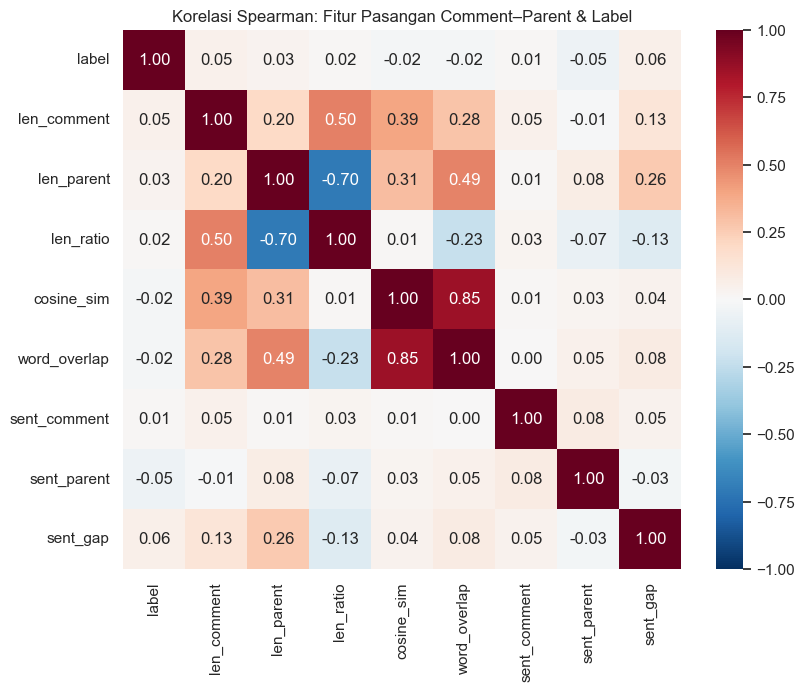

In [146]:
pairs = [("len_comment", "len_parent"), ("sent_comment", "sent_parent")]
corr_rows = []
for name, g in ctx.groupby("label_name"):
    for a, b in pairs:
        corr_rows.append({"Label": name, "Pasangan": f"{a} vs {b}",
                          "Spearman rho": spearmanr(g[a], g[b]).statistic})
corr_cp = pd.DataFrame(corr_rows).pivot(index="Pasangan", columns="Label", values="Spearman rho").round(3)
display(corr_cp)

plt.figure(figsize=(9, 7))
corr = ctx[["label"] + features].corr(method="spearman")
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("Korelasi Spearman: Fitur Pasangan Comment–Parent & Label")
save_fig("04_pair_feature_correlation")
plt.show()


#### Insight
- Pada kelas sarkas, hubungan comment dengan parent **lebih lemah**:
  - Panjang: ρ = 0,144 (sarkas) vs 0,238 (non-sarkas).
  - Sentimen: ρ = 0,059 (sarkas) vs 0,111 (non-sarkas).
- Artinya komentar sarkas cenderung **tidak mengikuti** nada dan panjang parent-nya, sedangkan komentar non-sarkas lebih sering "menyambung" parent secara langsung.

### 6.5 Kemiripan Leksikal dan Panjang

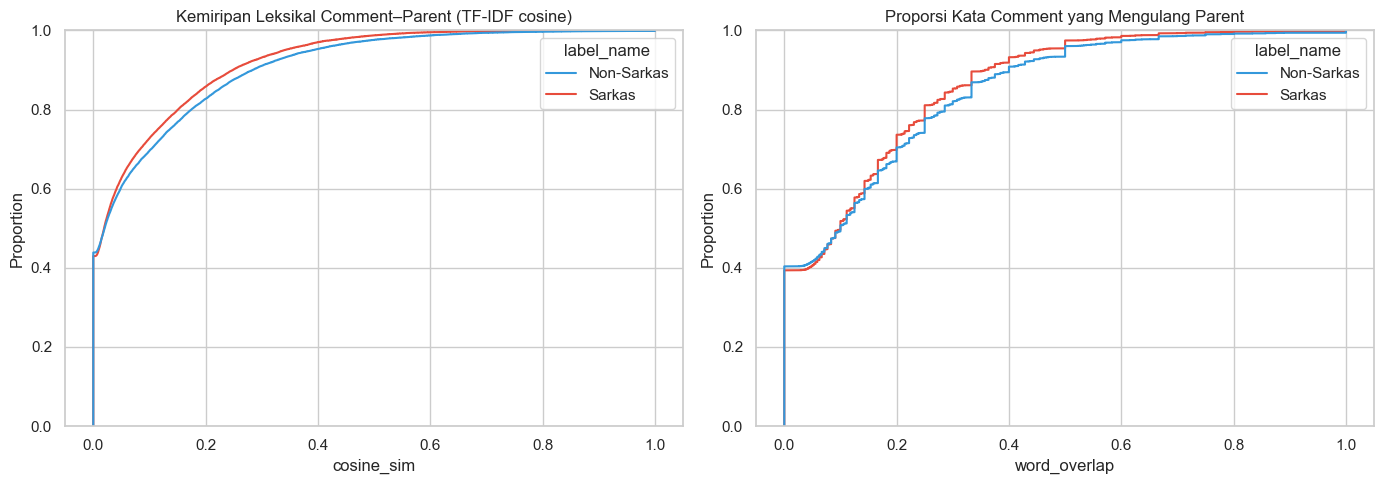

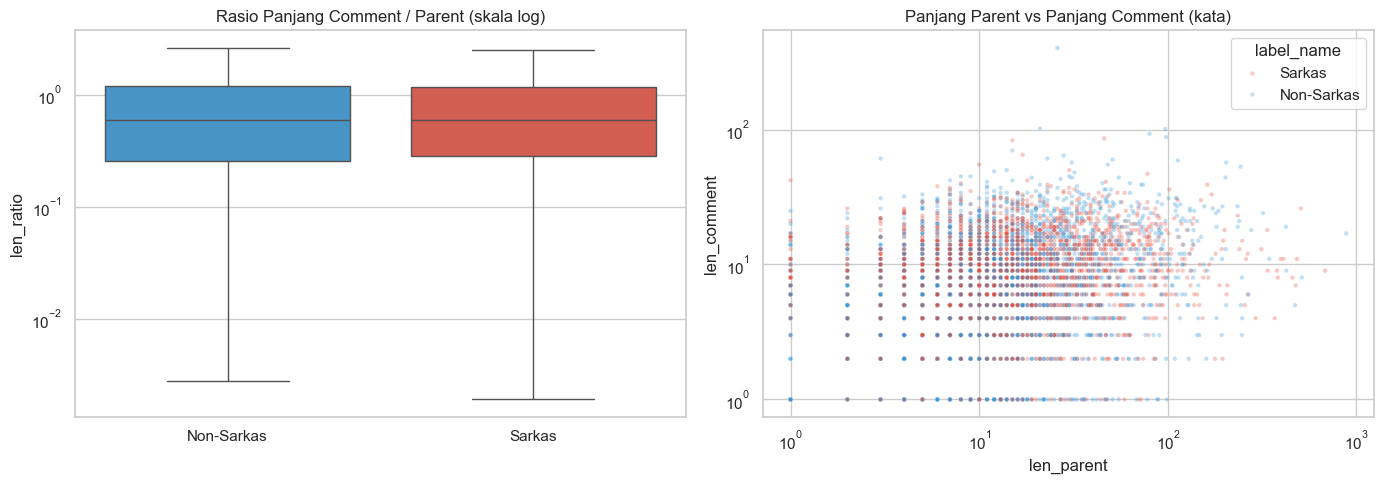

In [147]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.ecdfplot(data=ctx, x="cosine_sim", hue="label_name", palette=PALETTE, ax=axes[0])
axes[0].set_title("Kemiripan Leksikal Comment–Parent (TF-IDF cosine)")
sns.ecdfplot(data=ctx, x="word_overlap", hue="label_name", palette=PALETTE, ax=axes[1])
axes[1].set_title("Proporsi Kata Comment yang Mengulang Parent")
plt.tight_layout()
save_fig("04_context_similarity")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=ctx, x="label_name", y="len_ratio", hue="label_name", palette=PALETTE,
            showfliers=False, legend=False, ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Rasio Panjang Comment / Parent (skala log)")
axes[0].set_xlabel("")
sample_plot = ctx.sample(5_000, random_state=SEED)
sns.scatterplot(data=sample_plot, x="len_parent", y="len_comment", hue="label_name",
                palette=PALETTE, alpha=0.3, s=10, ax=axes[1])
axes[1].set(xscale="log", yscale="log", title="Panjang Parent vs Panjang Comment (kata)")
plt.tight_layout()
save_fig("04_length_coupling")
plt.show()


#### Insight
- Kemiripan kata (TF-IDF cosine dan word overlap) hampir sama pada kedua kelas, bahkan sedikit lebih rendah pada sarkas. Sarkasme bukan soal mengulang kata parent, melainkan **pembalikan makna atau nada**.

### 6.6 Kontras Sentimen Parent × Comment

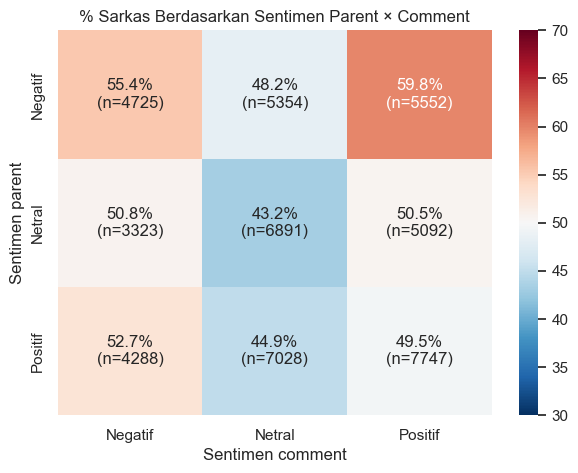

In [148]:
bins = [-1.01, -0.05, 0.05, 1.01]          # ambang standar VADER
names = ["Negatif", "Netral", "Positif"]
ctx["sent_parent_cat"] = pd.cut(ctx["sent_parent"], bins, labels=names)
ctx["sent_comment_cat"] = pd.cut(ctx["sent_comment"], bins, labels=names)

rate = ctx.pivot_table(index="sent_parent_cat", columns="sent_comment_cat",
                       values="label", aggfunc="mean", observed=False) * 100
count = ctx.pivot_table(index="sent_parent_cat", columns="sent_comment_cat",
                        values="label", aggfunc="size", observed=False)
annot = rate.round(1).astype(str) + "%\n(n=" + count.astype(str) + ")"

plt.figure(figsize=(7, 5))
sns.heatmap(rate, annot=annot, fmt="", cmap="RdBu_r", center=50, vmin=30, vmax=70)
plt.title("% Sarkas Berdasarkan Sentimen Parent × Comment")
plt.xlabel("Sentimen comment")
plt.ylabel("Sentimen parent")
save_fig("04_sentiment_contrast_heatmap")
plt.show()


#### Insight
- Kombinasi **parent negatif + comment positif** memiliki proporsi sarkas tertinggi (**59,8%**), sedangkan pasangan netral–netral terendah (43,2%).
- Pola ini sesuai dengan definisi sarkasme: pujian atau nada positif yang dipakai untuk menanggapi situasi negatif.

### 6.7 Contoh Kualitatif: Parent Negatif, Comment Positif, Label Sarkas

In [149]:
contrast = ctx[(ctx["label"] == 1) & (ctx["sent_parent"] < -0.5) & (ctx["sent_comment"] > 0.5)]
with pd.option_context("display.max_colwidth", 120):
    display(contrast[["parent_comment", "comment", "sent_parent", "sent_comment"]].head(5))


,parent_comment,comment,sent_parent,sent_comment
25010,"Residents voted by a margin of 73% to ban red light cameras, so the cities are suing their constituents to overturn ...",I'm sure a lawsuit to overturn a supermajority of the public's will is going to lead to really favorable election re...,-0.8519,0.5849
25037,"Everyone in this thread is going on about Joan getting raped, but what about the rape of a very young Dick Whitman?","He's a male, he can't be raped.",-0.9452,0.5667
25042,U.S. Government Funding $1.86 Million Study In Attempt to Link Cannabis To Domestic Violence,Another brilliant idea.,-0.6249,0.5859
25058,"Woman, 30, bombarded with anti-UKIP hate calls after party's typo puts her mobile number on billboard","Ah, the ""tolerant left"", showing us all how much better than us they are, yet again!",-0.5267,0.6476
25060,"3 Month Jail sentence for hit-and-run driver in cyclist's death, to be served on weekends","Wow, really throwing the book at him, eh?",-0.5574,0.5859


### Kesimpulan Analisis Konteks
Sarkasme tidak dapat dikenali dari comment atau parent secara terpisah, karena setiap fitur tunggal hanya memberi sinyal lemah. Polanya muncul dari **interaksi** keduanya, terutama kontras sentimen. Temuan ini mendukung keputusan proposal untuk memberikan input **parent comment + target comment** ke model transformer, yang mampu menangkap hubungan antarkalimat melalui mekanisme self-attention.

## 7. Kesiapan Data untuk Modeling

### 7.1 Panjang Token Pasangan Parent + Comment (Justifikasi `max_length = 256`)

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (639 > 512). Running this sequence through the model will result in indexing errors
[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (655 > 512). Running this sequence through the model will result in indexing errors


,Median,P95,P99,Max,% terpotong (> 256)
Model,,,,,
roberta-base,32.0,108.0,204.0,1426,0.59
distilbert-base-uncased,31.0,106.0,201.0,1415,0.61


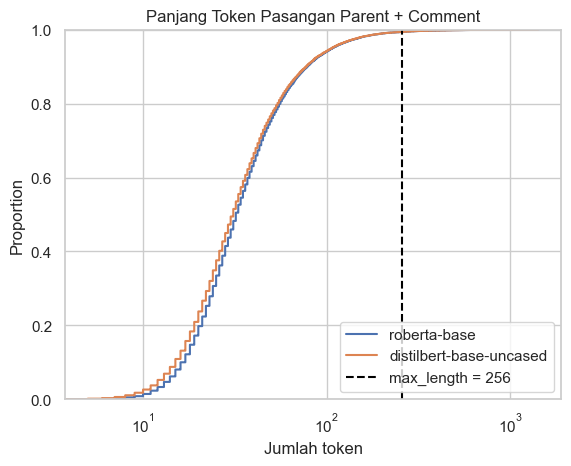

In [150]:
MAX_LEN = 256
tok_sample = df.sample(20_000, random_state=SEED)
rows = []
for model_name in ["roberta-base", "distilbert-base-uncased"]:
    tok = AutoTokenizer.from_pretrained(model_name)
    enc = tok(tok_sample["parent_clean"].tolist(), tok_sample["comment_clean"].tolist(), truncation=False)
    n_tok = pd.Series([len(ids) for ids in enc["input_ids"]])
    rows.append({"Model": model_name, "Median": n_tok.median(), "P95": n_tok.quantile(0.95),
                 "P99": n_tok.quantile(0.99), "Max": n_tok.max(),
                 f"% terpotong (> {MAX_LEN})": (n_tok > MAX_LEN).mean() * 100})
    sns.ecdfplot(n_tok, label=model_name)
token_lengths = pd.DataFrame(rows).set_index("Model").round(2)
display(token_lengths)
token_lengths.to_csv(TAB_DIR / "eda_token_lengths.csv")

plt.axvline(MAX_LEN, color="black", ls="--", label=f"max_length = {MAX_LEN}")
plt.xscale("log")
plt.title("Panjang Token Pasangan Parent + Comment")
plt.xlabel("Jumlah token")
plt.legend()
save_fig("08_token_length_ecdf")
plt.show()


#### Insight
- Median panjang pasangan ±32 token dan P99 ±204 token.
- Dengan `max_length = 256`, hanya **0,59% (RoBERTa)** dan **0,61% (DistilBERT)** pasangan yang terpotong, sehingga nilai 256 pada proposal sudah mencakup lebih dari 99% data.
- Pada tahap tokenisasi, parent diletakkan di posisi pertama dengan `truncation="only_first"`, sehingga jika input terlalu panjang yang dipotong adalah parent, bukan comment target.

### 7.2 Representativitas Subset 200.000 Pasangan

In [151]:
N_PER_CLASS = 100_000
subset = df.groupby("label", group_keys=False).sample(N_PER_CLASS, random_state=SEED)

check = pd.DataFrame({
    "Full: % sarkas": [df["label"].mean() * 100],
    "Subset: % sarkas": [subset["label"].mean() * 100],
    "Full: median kata comment": [df["comment_clean"].str.split().str.len().median()],
    "Subset: median kata comment": [subset["comment_clean"].str.split().str.len().median()],
    "Full: median kata parent": [df["parent_clean"].str.split().str.len().median()],
    "Subset: median kata parent": [subset["parent_clean"].str.split().str.len().median()],
}).T.round(2)
display(check)

top_sub = df["subreddit"].value_counts().head(10).index
sub_cmp = pd.DataFrame({
    "Full (%)": df["subreddit"].value_counts(normalize=True)[top_sub] * 100,
    "Subset (%)": subset["subreddit"].value_counts(normalize=True)[top_sub] * 100,
}).round(2)
year_cmp = pd.DataFrame({
    "Full (%)": df["date"].str[:4].value_counts(normalize=True).sort_index() * 100,
    "Subset (%)": subset["date"].str[:4].value_counts(normalize=True).sort_index() * 100,
}).round(2)
display(sub_cmp)
display(year_cmp)


,0
Full: % sarkas,49.87
Subset: % sarkas,50.00
Full: median kata comment,9.00
Subset: median kata comment,9.00
Full: median kata parent,14.00
Subset: median kata parent,14.00


,Full (%),Subset (%)
subreddit,,
AskReddit,6.50,6.48
politics,3.89,3.93
worldnews,2.61,2.67
leagueoflegends,2.07,2.11
pcmasterrace,1.87,1.85
funny,1.78,1.77
news,1.68,1.66
pics,1.60,1.61
todayilearned,1.40,1.40


,Full (%),Subset (%)
date,,
2009,0.18,0.17
2010,0.52,0.53
2011,1.26,1.25
2012,2.71,2.67
2013,6.31,6.34
2014,13.64,13.55
2015,28.37,28.42
2016,47.00,47.07


#### Insight
- Subset diambil 100.000 pasangan per label dengan seed tetap (`SEED = 42`).
- Distribusi subreddit, tahun, dan median panjang comment/parent pada subset hampir identik dengan data penuh (selisih < 0,1 poin persen). Ini menjadi dasar bahwa subset "dipilih secara terkontrol" dan representatif.

## 8. Kesimpulan EDA

### 8.1 Kesimpulan

1. **Kualitas data baik, noise kecil.**
   Dari 1.010.826 pasangan mentah, tersisa **1.004.249 pasangan (99,35%)** setelah preprocessing sesuai proposal. Data yang dibuang meliputi comment kosong (55), teks kosong setelah cleaning (1.408), label bertentangan (142), pasangan duplikat (1.147), dan artefak anotasi `/s` (3.825). Proporsi label tetap seimbang (49,87% sarkas), sehingga *accuracy* tetap valid digunakan bersama *precision*, *recall*, dan *F1-score*.

2. **Fitur permukaan bukan pembeda utama sarkasme.**
   Median panjang comment sama pada kedua kelas (9 kata). Distribusi *score* saling tumpang tindih. Sarcasm rate per hari hanya berkisar 48,82%–50,45%. Karena dataset ini diseimbangkan melalui proses sampling, pola metadata tersebut tidak mencerminkan prevalensi sarkasme di Reddit yang sebenarnya.

3. **Pola leksikal ada, tetapi tidak cukup.**
   Komentar sarkas banyak memakai afirmasi berlebihan dan kata positif semu (*yeah*, *sure*, *obviously*, *good thing*, *makes perfect sense*). Namun kosakatanya banyak tumpang tindih dengan komentar non-sarkas, sehingga pendekatan berbasis frekuensi kata saja tidak memadai.

4. **Konteks parent comment adalah kunci.**
   - Hubungan comment dengan parent lebih lemah pada kelas sarkas. Korelasi panjangnya ρ = 0,144 vs 0,238, dan korelasi sentimennya ρ = 0,059 vs 0,111. Artinya komentar sarkas cenderung tidak mengikuti nada parent-nya.
   - Kombinasi **parent negatif + comment positif** menghasilkan proporsi sarkas tertinggi (**59,8%**), sedangkan netral–netral terendah (43,2%).
   - Setiap fitur tunggal hanya memiliki effect size kecil (|Cliff's δ| ≤ 0,07). Sinyal sarkasme muncul dari **interaksi** comment dan parent, bukan dari salah satunya saja.

   Temuan ini mendukung keputusan proposal untuk memberikan input **parent comment + target comment** ke model transformer.

5. **Parameter eksperimen pada proposal tervalidasi.**
   - `max_length = 256` hanya memotong **0,59% (RoBERTa)** dan **0,61% (DistilBERT)** pasangan (P99 ≈ 204 token).
   - Subset **200.000 pasangan** (100.000 per label, `SEED = 42`) memiliki distribusi subreddit, tahun, dan panjang teks yang hampir identik dengan data penuh (selisih < 0,1 poin persen).
